# PRICING DINÁMICO DE HABITACIONES DE HOTEL

*Cristian Rubio Barato*

*Francisco Martínez Esteso*

*José Vicente García López*

*Víctor Ortega Gómez*


## ÍNDICE

1. [PREPROCESAMIENTO](#1-preprocesamiento)    
   1.1 [Instalar MLRun](#11-instalar-mlrun)   
   1.2 [Crear proyecto](#12-crear-proyecto)   
   1.3 [Preprocesamiento dataset](#13-preprocesamiento-dataset)   

2. [ENTRENAMIENTO](#2-entrenamiento)  
   2.1 [Funcion entrenamiento](#21-funcion-entrenamiento)   
   2.2 [Resumen entrenamiento](#22-resumen-entrenamiento)   

3. [DESPLIEGUE E INFERENCIA](#3-despliegue-e-inferencia)  

In [1]:
random_state = 27912

## 1. PREPROCESAMIENTO

### 1.1 Instalar MLRun

In [2]:
# Install MLRun and sklearn, run this only once (restart the notebook after the install !!!)
%pip install mlrun scikit-learn~=1.5.1 numpy~=1.26.4

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 18.2/18.2 MB 10.4 MB/s eta 0:00:00a 0:00:01
  Attempting uninstall: numpy
    Found existing installation: numpy 1.23.3
    Uninstalling numpy-1.23.3:
      Successfully uninstalled numpy-1.23.3
ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
numba 0.56.2 requires numpy<1.24,>=1.18, but you have numpy 1.26.4 which is incompatible.

[notice] A new release of pip is available: 24.3.1 -> 25.0.1
[notice] To update, run: pip install --upgrade pip
Note: you may need to restart the kernel to use updated packages.


### 1.2 Crear proyecto

In [2]:
import mlrun

In [3]:
project = mlrun.get_or_create_project("pricing-hotel", "./", user_project=True)

> 2025-04-20 09:29:14,604 [info] Project loaded successfully: {"project_name":"pricing-hotel-jovyan"}


### 1.3 Preprocesamiento dataset

In [18]:
%%writefile hotel_prep.py

from datetime import datetime
import joblib
import pandas as pd
import numpy as np
from sklearn.preprocessing import StandardScaler
import mlrun

@mlrun.handler(outputs=["dataset", "label_column"])
def hotel_booking_preprocessor(context):
    df = pd.read_csv('hotel_booking.csv')
    
    df = df.dropna(subset=["adr"])
    df.fillna(0, inplace=True)
    
    df["reservation_status_date"] = pd.to_datetime(df["reservation_status_date"])
    df["reservation_status_year"]  = df["reservation_status_date"].dt.year
    df["reservation_status_date"]  = df["reservation_status_date"].dt.date
    df["arrival_date_month"]       = pd.to_datetime(df["arrival_date_month"], format="%B").dt.month
    df["children"] = df["children"].astype(int)
    
    start_date = datetime.strptime("2015-07", "%Y-%m").date()
    df = df[df['reservation_status_date'] >= start_date]
    
    columns_to_drop = [
        "days_in_waiting_list", "name", "email", "phone-number",
        "credit_card", "agent", "company", "booking_changes",
        "arrival_date_week_number"
    ]
    df.drop(columns=columns_to_drop, inplace=True, errors="ignore")
    
    df = df[~((df["adults"] == 0) & (df["children"] == 0) & (df["babies"] == 0))]
    
    Q1 = np.percentile(df["adr"], 25)
    Q3 = np.percentile(df["adr"], 75)
    IQR = Q3 - Q1
    lower_bound = Q1 - 1.5 * IQR
    upper_bound = Q3 + 1.5 * IQR
    df = df[(df["adr"] >= lower_bound) & (df["adr"] <= upper_bound)]
    
    categorical_vars = df.select_dtypes(include=['object', 'category']).columns.tolist()
    df = pd.get_dummies(df, columns=categorical_vars, drop_first=True)
    
    numerical_cols = df.select_dtypes(include=["int64", "float64"]).columns
    scaler = StandardScaler()
    df[numerical_cols] = scaler.fit_transform(df[numerical_cols])
    
    joblib.dump(scaler, "scaler.pkl")  # guardar como archivo binario
    context.log_artifact("scaler", local_path="scaler.pkl") 
    
    return df, "adr"

Overwriting hotel_prep.py


In [19]:
# Registrar la función en MLRun
hotel_prep_fn = project.set_function(
    "hotel_prep.py",                  
    name="hotel-prep",                    
    kind="job",                           
    image="mlrun/mlrun",                 
    handler="hotel_booking_preprocessor"  
)

project.save()


In [20]:
hotel_pricing_run = project.run_function("hotel-prep", local=True)

> 2025-04-20 09:36:14,124 [warning] it is recommended to use k8s secret (specify secret_name), specifying the aws_access_key/aws_secret_key directly is unsafe
> 2025-04-20 09:36:14,145 [info] Storing function: {"db":"http://mlrun-api:8080","name":"hotel-prep-hotel-booking-preprocessor","uid":"b71ccaebe8c54bf9b06a178d85dc513d"}


project,uid,iter,start,state,kind,name,labels,inputs,parameters,results,artifacts
pricing-hotel-jovyan,...85dc513d,0,Apr 20 09:36:14,completed,run,hotel-prep-hotel-booking-preprocessor,kind=localowner=jovyanhost=mlrun-jupyter-84d9487f79-hjmm8,,,label_column=adr,scalerdataset


> 2025-04-20 09:36:17,903 [info] Run execution finished: {"name":"hotel-prep-hotel-booking-preprocessor","status":"completed"}


In [22]:
hotel_pricing_run.state()

'completed'

In [23]:
hotel_pricing_run.outputs

{'label_column': 'adr',
 'scaler': 'store://artifacts/pricing-hotel-jovyan/hotel-prep-hotel-booking-preprocessor_scaler:latest@b71ccaebe8c54bf9b06a178d85dc513d',
 'dataset': 'store://datasets/pricing-hotel-jovyan/hotel-prep-hotel-booking-preprocessor_dataset:latest@b71ccaebe8c54bf9b06a178d85dc513d'}

## 2. ENTRENAMIENTO

### 2.1 Funcion entrenamiento

In [24]:
trainer = mlrun.import_function("hub://auto_trainer")

In [28]:
metrics = {
    "R2": "sklearn.metrics.r2_score",
    "MAE": "sklearn.metrics.mean_absolute_error",
    "MSE": "sklearn.metrics.mean_squared_error",
    "RMSE": "sklearn.metrics.root_mean_squared_error",
    "Max Error": "sklearn.metrics.max_error"
}

# Ejecutamos el paso de entrenamiento con:
trainer_run = project.run_function(
    trainer,
    handler="train",
    inputs={"dataset": hotel_pricing_run.outputs["dataset"]},
    params={
        "model_class": "sklearn.ensemble.RandomForestRegressor",
        "train_test_split_size": 0.2,
        "label_columns": "adr",
        "model_name": "hotel_price_rf",
        # Le decimos al auto_trainer qué métricas calcular
        "_metrics": metrics,  
    },
    # Ponemos los mejores hiperparámetros (los que seleccionamos en el hito 3):
    hyperparams={
        "n_estimators": [100],
        "max_depth": [None],
        "min_samples_split": [5],
    },
    selector="max.R2",
    local=True
)

> 2025-04-20 10:04:42,203 [info] Storing function: {"db":"http://mlrun-api:8080","name":"auto-trainer-train","uid":"1ee0c51af901480c9ee171feb596d888"}
> 2025-04-20 10:04:42,825 [info] Sample set not given, using the whole training set as the sample set
> 2025-04-20 10:04:43,057 [info] training 'hotel_price_rf'


/opt/conda/lib/python3.9/site-packages/sklearn/metrics/_regression.py:492: FutureWarning:

'squared' is deprecated in version 1.4 and will be removed in 1.6. To calculate the root mean squared error, use the function'root_mean_squared_error'.

<__array_function__ internals>:180: RuntimeWarning:

Converting input from bool to <class 'numpy.uint8'> for compatibility.



> 2025-04-20 10:12:57,983 [info] best iteration=1, used criteria max.R2


project,uid,iter,start,state,kind,name,labels,inputs,parameters,results,artifacts
pricing-hotel-jovyan,...b596d888,0,Apr 20 10:04:42,completed,run,auto-trainer-train,kind=localowner=jovyan,dataset,"model_class=sklearn.ensemble.RandomForestRegressortrain_test_split_size=0.2label_columns=adrmodel_name=hotel_price_rf_metrics={'R2': 'sklearn.metrics.r2_score', 'MAE': 'sklearn.metrics.mean_absolute_error', 'MSE': 'sklearn.metrics.mean_squared_error', 'RMSE': 'sklearn.metrics.root_mean_squared_error', 'Max Error': 'sklearn.metrics.max_error'}",best_iteration=1R2=0.8587575503737809MAE=0.1863916073950932MSE=0.1412093840744292RMSE=0.3757783709507896Max Error=4.637059221580408mean_absolute_error=0.1863916073950932r2_score=0.8587575503737809root_mean_squared_error=0.3757783709507896mean_squared_error=0.1412093840744292,feature-importancetest_setmodeliteration_resultsparallel_coordinates


> 2025-04-20 10:12:59,076 [info] Run execution finished: {"name":"auto-trainer-train","status":"completed"}


### 2.2 Resumen entrenamiento

In [29]:
trainer_run.outputs

{'best_iteration': 1,
 'R2': 0.8587575503737809,
 'MAE': 0.1863916073950932,
 'MSE': 0.1412093840744292,
 'RMSE': 0.3757783709507896,
 'Max Error': 4.637059221580408,
 'mean_absolute_error': 0.1863916073950932,
 'r2_score': 0.8587575503737809,
 'root_mean_squared_error': 0.3757783709507896,
 'mean_squared_error': 0.1412093840744292,
 'feature-importance': 's3://mlrun/projects/pricing-hotel-jovyan/artifacts/auto-trainer-train/1/feature-importance.html',
 'test_set': 'store://datasets/pricing-hotel-jovyan/auto-trainer-train_test_set:latest@1ee0c51af901480c9ee171feb596d888',
 'model': 'store://models/pricing-hotel-jovyan/hotel_price_rf:latest@1ee0c51af901480c9ee171feb596d888',
 'iteration_results': 's3://mlrun/projects/pricing-hotel-jovyan/artifacts/auto-trainer-train/0/iteration_results.csv',
 'parallel_coordinates': 'store://artifacts/pricing-hotel-jovyan/auto-trainer-train_parallel_coordinates:latest@1ee0c51af901480c9ee171feb596d888'}

## 3. DESPLIEGUE E INFERENCIA

In [31]:
serving_fn = project.set_function(
    func="",
    name="serving",
    image="mlrun/mlrun",
    kind="serving",
    requirements=["scikit-learn~=1.5.1"]
)

> 2025-04-20 10:17:58,805 [info] Function code not specified, setting entry point to image


In [33]:
serving_fn.add_model(
    "hotel-pricing-model",  
    model_path=trainer_run.outputs["model"],  
    class_name="mlrun.frameworks.sklearn.SklearnModelServer" 
)

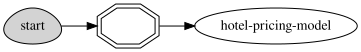

In [34]:
serving_fn.spec.graph.plot(rankdir="LR")

In [35]:
server = serving_fn.to_mock_server()

> 2025-04-20 10:19:01,392 [warning] run command, file or code were not specified
> 2025-04-20 10:19:04,802 [info] model hotel-pricing-model was loaded
> 2025-04-20 10:19:04,803 [info] Loaded ['hotel-pricing-model']


In [36]:
# Verificamos que el endpoint está listo
server.test("/v2/models/", method="GET")

{'models': ['hotel-pricing-model']}

In [45]:
import numpy as np
import pandas as pd

# Como nuestro dataset después del preprocesamiento tiene 1167 columnas, 
# la inferencia la hacemos de forma aleatoria

dataset_uri = hotel_pricing_run.outputs["dataset"]

# Cargar el dataset en un DataFrame
df = mlrun.get_dataitem(dataset_uri).as_df()
X = df.drop(columns=['adr'])

# Usamos el mismo orden de columnas que en el dataset final
column_names = X.columns.tolist()
example_row = []

for col in X.dtypes.index:
    dtype = X.dtypes[col]

    if dtype == "bool":
        value = bool(np.random.randint(0, 2))  
    elif dtype == "int32" or dtype == "int64":
        value = int(np.random.randint(-2, 2))  
    elif dtype == "float64":
        value = float(np.random.normal(0, 1)) 
    else:
        value = 0

    example_row.append(value)

# Construimos el input que espera el modelo
example_input = {
    "inputs": [example_row]
}


In [46]:
response = server.test("/v2/models/hotel-pricing-model/infer", body=example_input)
print(response)

{'id': '5c32fd6e57a041179ec965aa0496c603', 'model_name': 'hotel-pricing-model', 'outputs': [-0.4484138958171182], 'timestamp': '2025-04-20 10:25:45.278519+00:00'}


/opt/conda/lib/python3.9/site-packages/sklearn/base.py:493: UserWarning:

X does not have valid feature names, but RandomForestRegressor was fitted with feature names



In [71]:
project.deploy_function(serving_fn)

> 2025-04-20 12:21:34,589 [info] Starting remote function deploy
2025-04-20 12:21:34  (info) Deploying function
2025-04-20 12:21:34  (info) Building
2025-04-20 12:21:34  (info) Staging files and preparing base images
2025-04-20 12:21:34  (warn) Using user provided base image, runtime interpreter version is provided by the base image
2025-04-20 12:21:34  (info) Building processor image
Failed to deploy. Details:

Error - Job failed. Job logs:
error checking push permissions -- make sure you entered the correct tag name, and that you are authenticated correctly, and try again: checking push permission for "index.docker.io/josevigl/processor-pricing-hotel-jovyan-serving:latest": POST https://index.docker.io/v2/josevigl/processor-pricing-hotel-jovyan-serving/blobs/uploads/: UNAUTHORIZED: authentication required; [map[Action:pull Class: Name:josevigl/processor-pricing-hotel-jovyan-serving Type:repository] map[Action:push Class: Name:josevigl/processor-pricing-hotel-jovyan-serving Type:repos

RunError: Function serving deployment failed

In [ ]:
response = serving_fn.invoke("/v2/models/hotel-pricing-model/infer", body=example_input)

print("Predicción del precio (adr):", response)